# Lab 8: Grayscale to RGB Color Prediction using CIFAR-10

**Objective**: Train a CNN model to predict RGB color channels from grayscale images.

The model learns semantic colorization - understanding that grass is green, sky is blue, etc.

## 1. Import Libraries

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.16.2


## 2. Load and Prepare CIFAR-10 Dataset

In [2]:
# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

# CIFAR-10 classes (filtering real photos - excluding handwriting)
# 0: airplane, 1: automobile, 2: bird, 3: cat, 4: deer, 5: dog, 6: frog, 7: horse, 8: ship, 9: truck
# All classes are real photos, no handwriting in CIFAR-10

print(f"Training data shape: {x_train.shape}")
print(f"Testing data shape: {x_test.shape}")
print(f"Data range: {x_train.min()} to {x_train.max()}")

Training data shape: (50000, 32, 32, 3)
Testing data shape: (10000, 32, 32, 3)
Data range: 0 to 255


In [3]:
# Normalize RGB images to [0, 1]
x_train_rgb = x_train.astype('float32') / 255.0
x_test_rgb = x_test.astype('float32') / 255.0

# Convert RGB to Grayscale using TensorFlow
x_train_gray = tf.image.rgb_to_grayscale(x_train_rgb).numpy()
x_test_gray = tf.image.rgb_to_grayscale(x_test_rgb).numpy()

print(f"Grayscale training shape: {x_train_gray.shape}")  # (50000, 32, 32, 1)
print(f"RGB training shape: {x_train_rgb.shape}")         # (50000, 32, 32, 3)
print(f"Grayscale test shape: {x_test_gray.shape}")       # (10000, 32, 32, 1)
print(f"RGB test shape: {x_test_rgb.shape}")              # (10000, 32, 32, 3)

2025-12-05 10:33:51.663036: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2025-12-05 10:33:51.663199: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2025-12-05 10:33:51.663202: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2025-12-05 10:33:51.663387: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-12-05 10:33:51.663401: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Grayscale training shape: (50000, 32, 32, 1)
RGB training shape: (50000, 32, 32, 3)
Grayscale test shape: (10000, 32, 32, 1)
RGB test shape: (10000, 32, 32, 3)


## 3. Visualize Sample Images

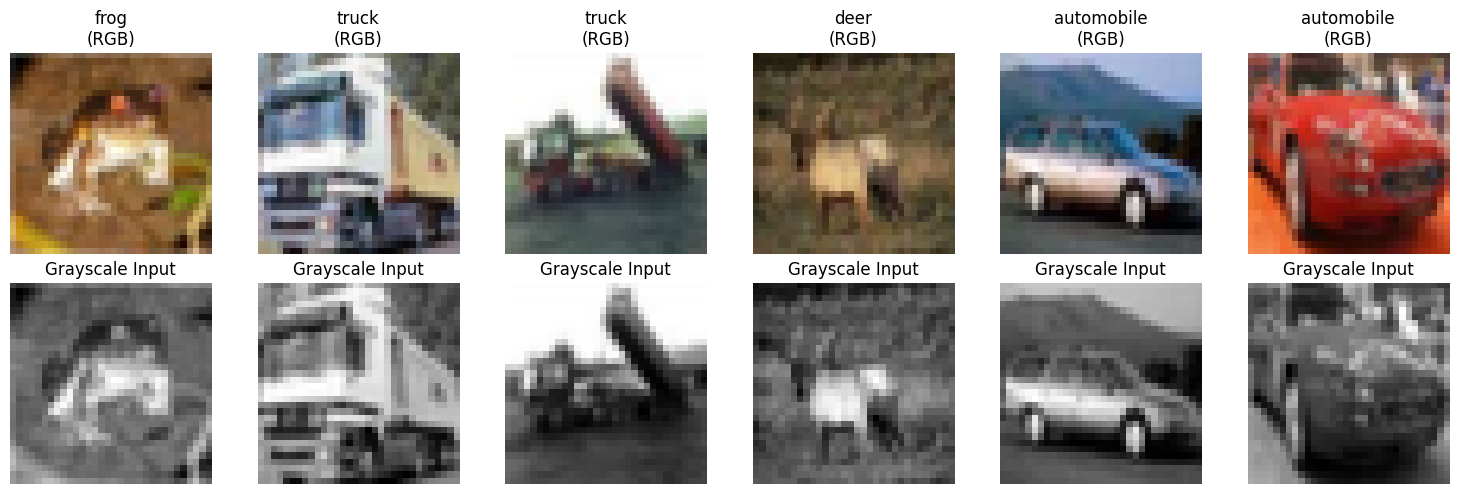

In [4]:
# Display some examples
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 
               'dog', 'frog', 'horse', 'ship', 'truck']

plt.figure(figsize=(15, 5))
for i in range(6):
    # Original RGB
    plt.subplot(2, 6, i + 1)
    plt.imshow(x_train_rgb[i])
    plt.title(f'{class_names[y_train[i][0]]}\n(RGB)')
    plt.axis('off')
    
    # Grayscale
    plt.subplot(2, 6, i + 7)
    plt.imshow(x_train_gray[i].squeeze(), cmap='gray')
    plt.title('Grayscale Input')
    plt.axis('off')

plt.tight_layout()
plt.show()

## 4. Build the Colorization Model

We'll use a simple U-Net inspired CNN architecture:
- **Encoder**: Extracts features from grayscale image
- **Decoder**: Reconstructs RGB color channels

In [5]:
def build_colorization_model():
    """
    Simple CNN model for grayscale to RGB colorization
    Input: Grayscale image (32, 32, 1)
    Output: RGB image (32, 32, 3)
    """
    model = keras.Sequential([
        # Encoder - Extract features
        layers.Conv2D(64, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 1)),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        
        # Decoder - Reconstruct colors
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        
        # Output layer - 3 channels for RGB
        layers.Conv2D(3, (3, 3), activation='sigmoid', padding='same')
    ])
    
    return model

# Create the model
model = build_colorization_model()
model.summary()

/Users/sumith/Desktop/5 sem/tfenv/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 3)      │         1,731 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 519,043 (1.98 MB)

 Trainable params: 519,043 (1.98 MB)

 Non-trainable params: 0 (0.00 B)

## 5. Compile the Model

In [6]:
# Compile the model
model.compile(
    optimizer='adam',
    loss='mse',  # Mean Squared Error for pixel-wise difference
    metrics=['mae']  # Mean Absolute Error as additional metric
)

print("Model compiled successfully!")

Model compiled successfully!


## 6. Train the Model

Training the model with grayscale input and RGB target. The model learns semantic colorization.

In [7]:
# Train the model
history = model.fit(
    x_train_gray,      # Input: Grayscale images (50000, 32, 32, 1)
    x_train_rgb,       # Target: RGB images (50000, 32, 32, 3)
    validation_data=(x_test_gray, x_test_rgb),
    epochs=20,
    batch_size=128,
    verbose=1
)

print("\nTraining completed!")

Epoch 1/20


2025-12-05 10:33:53.538088: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


391/391 ━━━━━━━━━━━━━━━━━━━━ 71s 174ms/step - loss: 0.0095 - mae: 0.0646 - val_loss: 0.0062 - val_mae: 0.0519
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 71s 181ms/step - loss: 0.0059 - mae: 0.0496 - val_loss: 0.0057 - val_mae: 0.0493
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 77s 198ms/step - loss: 0.0056 - mae: 0.0484 - val_loss: 0.0055 - val_mae: 0.0476
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 87s 223ms/step - loss: 0.0055 - mae: 0.0480 - val_loss: 0.0054 - val_mae: 0.0466
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 89s 227ms/step - loss: 0.0054 - mae: 0.0475 - val_loss: 0.0055 - val_mae: 0.0475
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 89s 226ms/step - loss: 0.0054 - mae: 0.0471 - val_loss: 0.0054 - val_mae: 0.0471
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 131s 336ms/step - loss: 0.0053 - mae: 0.0469 - val_loss: 0.0053 - val_mae: 0.0470
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 72s 183ms/step - loss: 0.0053 - mae: 0.0470 - val_loss: 0.0054 - val_mae: 0.0479
Epoch 9/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 98

## 7. Plot Training History

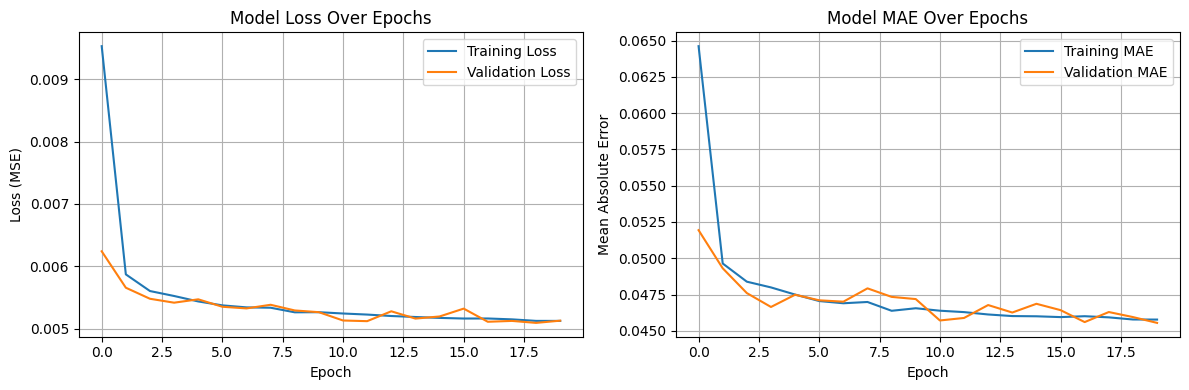

In [8]:
# Plot training and validation loss
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('Model MAE Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Mean Absolute Error')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## 8. Make Predictions and Visualize Results

Compare grayscale input, predicted RGB output, and ground truth RGB.

In [9]:
# Make predictions on test set
predictions = model.predict(x_test_gray[:10])

print(f"Predictions shape: {predictions.shape}")
print(f"Prediction range: [{predictions.min():.3f}, {predictions.max():.3f}]")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step
Predictions shape: (10, 32, 32, 3)
Prediction range: [0.003, 0.987]


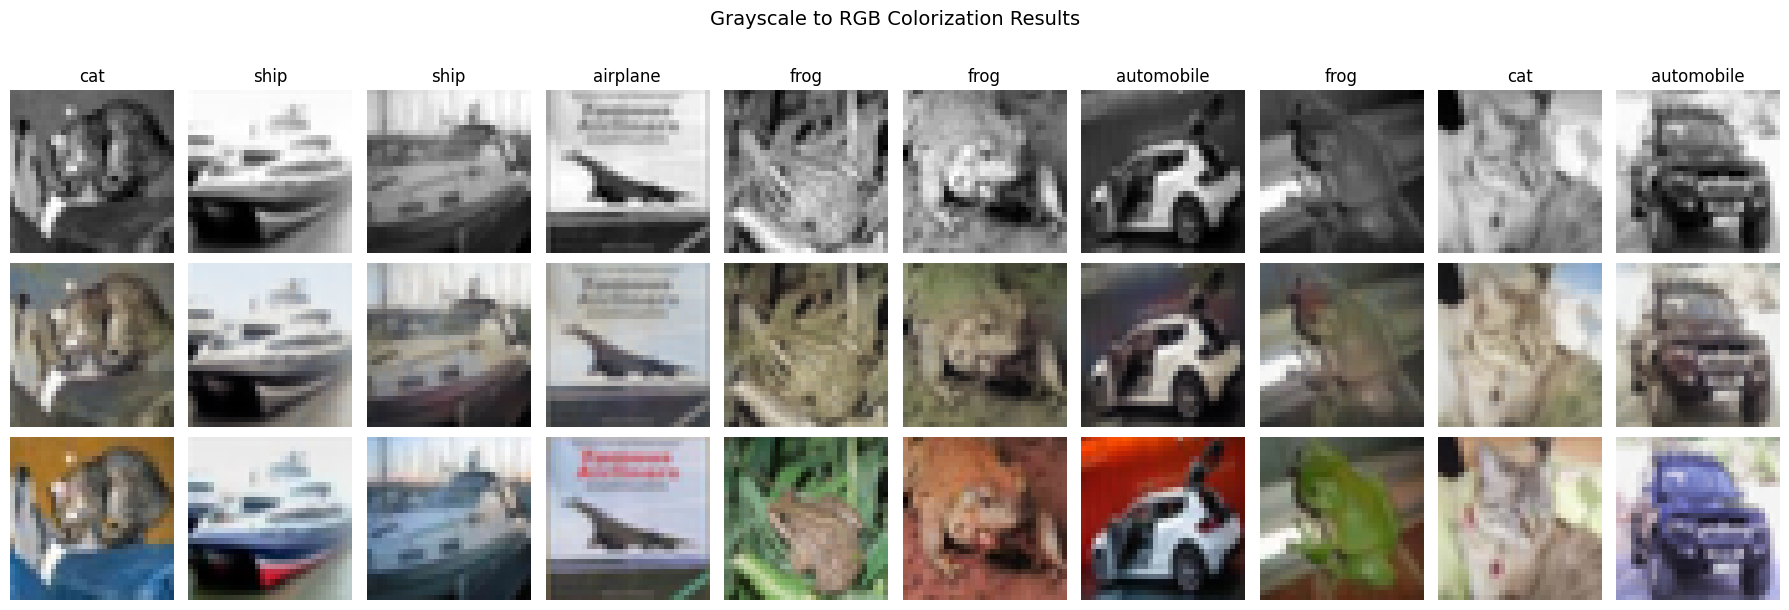

In [10]:
# Visualize colorization results
n_samples = 10

plt.figure(figsize=(18, 6))
for i in range(n_samples):
    # Grayscale input
    plt.subplot(3, n_samples, i + 1)
    plt.imshow(x_test_gray[i].squeeze(), cmap='gray')
    if i == 0:
        plt.ylabel('Grayscale\nInput', fontsize=12)
    plt.title(class_names[y_test[i][0]])
    plt.axis('off')
    
    # Predicted RGB
    plt.subplot(3, n_samples, n_samples + i + 1)
    plt.imshow(predictions[i])
    if i == 0:
        plt.ylabel('Predicted\nRGB', fontsize=12)
    plt.axis('off')
    
    # Ground truth RGB
    plt.subplot(3, n_samples, 2 * n_samples + i + 1)
    plt.imshow(x_test_rgb[i])
    if i == 0:
        plt.ylabel('Ground Truth\nRGB', fontsize=12)
    plt.axis('off')

plt.suptitle('Grayscale to RGB Colorization Results', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 9. Evaluate Model Performance

In [11]:
# Evaluate on test set
test_loss, test_mae = model.evaluate(x_test_gray, x_test_rgb, verbose=0)

print("=" * 50)
print("Model Evaluation on Test Set")
print("=" * 50)
print(f"Test Loss (MSE): {test_loss:.4f}")
print(f"Test MAE: {test_mae:.4f}")
print("=" * 50)

Model Evaluation on Test Set
Test Loss (MSE): 0.0051
Test MAE: 0.0455


## 10. Test on Specific Examples

Let's see how the model colorizes specific objects like sky, grass, animals, etc.

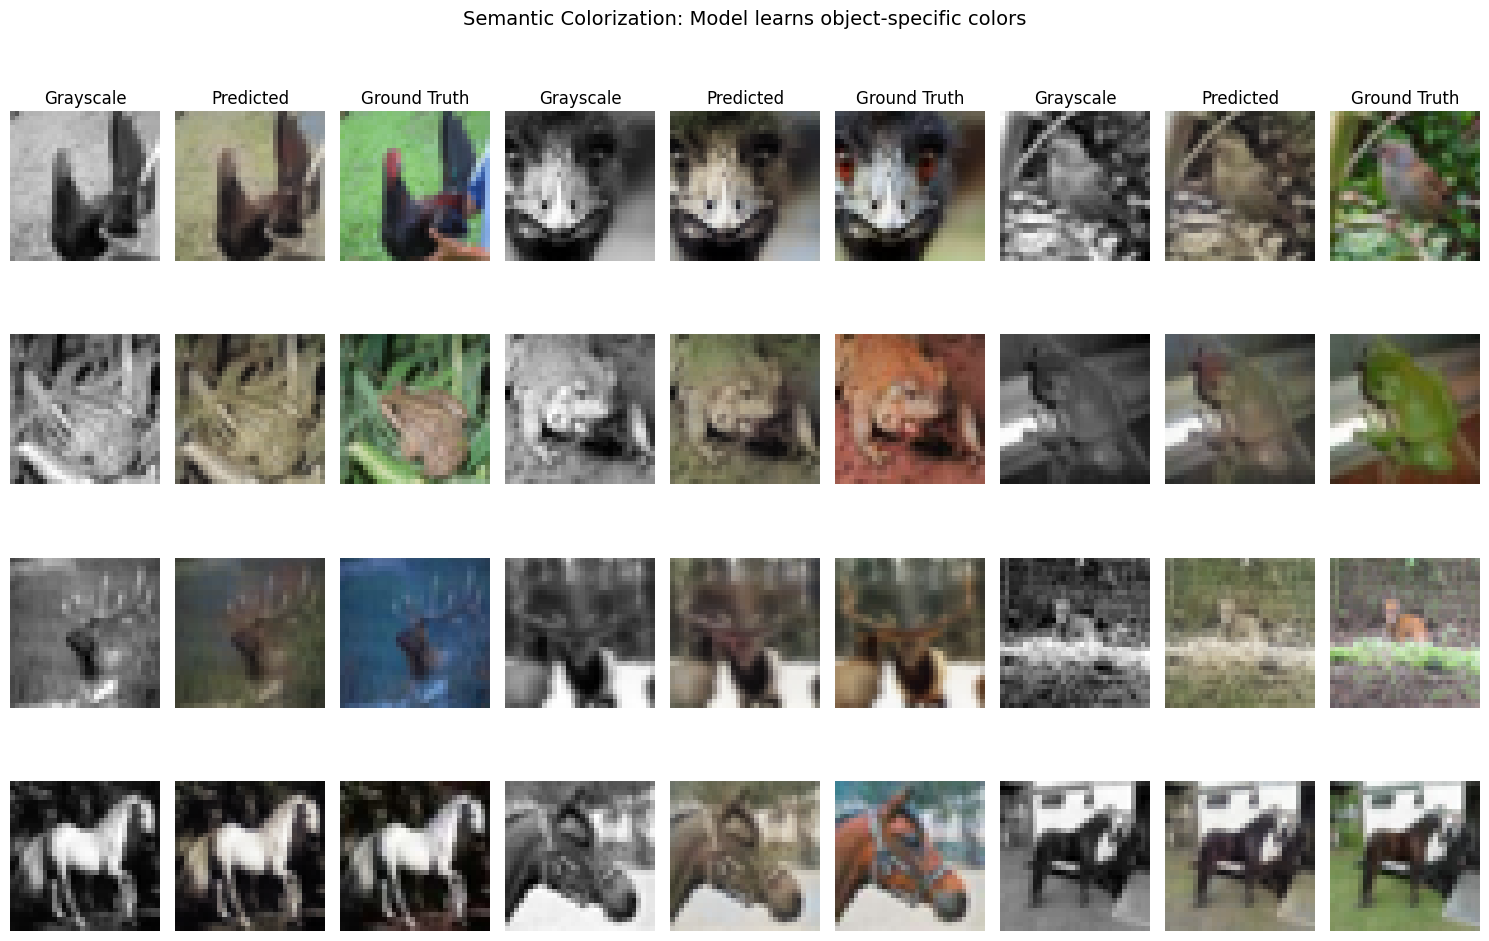

In [12]:
# Find examples of specific classes to show semantic colorization
# Find bird, frog, deer, and horse (classes with distinctive colors)
target_classes = [2, 6, 4, 7]  # bird, frog, deer, horse
class_indices = {cls: [] for cls in target_classes}

for i, label in enumerate(y_test[:1000]):
    if label[0] in target_classes and len(class_indices[label[0]]) < 3:
        class_indices[label[0]].append(i)

# Visualize semantic colorization
plt.figure(figsize=(15, 10))
row = 0
for cls in target_classes:
    indices = class_indices[cls]
    for col, idx in enumerate(indices[:3]):
        # Predict
        pred = model.predict(x_test_gray[idx:idx+1], verbose=0)[0]
        
        # Grayscale
        plt.subplot(len(target_classes), 9, row * 9 + col * 3 + 1)
        plt.imshow(x_test_gray[idx].squeeze(), cmap='gray')
        if col == 0:
            plt.ylabel(class_names[cls].capitalize(), fontsize=12, fontweight='bold')
        if row == 0:
            plt.title('Grayscale')
        plt.axis('off')
        
        # Predicted
        plt.subplot(len(target_classes), 9, row * 9 + col * 3 + 2)
        plt.imshow(pred)
        if row == 0:
            plt.title('Predicted')
        plt.axis('off')
        
        # Ground truth
        plt.subplot(len(target_classes), 9, row * 9 + col * 3 + 3)
        plt.imshow(x_test_rgb[idx])
        if row == 0:
            plt.title('Ground Truth')
        plt.axis('off')
    row += 1

plt.suptitle('Semantic Colorization: Model learns object-specific colors', fontsize=14, y=0.995)
plt.tight_layout()
plt.show()